# Prototype 5 — One-Session Strategy Robustness

Prototype 4 identified the **one-session strategy** as the strongest simple trading rule tested so far:

> A stock closes at least 8% below its previous close → enter at the next trading day's open → exit at that day's close.

The strategy produced a positive mean and median return after a simplified transaction-cost assumption, while longer holding periods performed poorly.

This final research notebook asks whether that result is **robust enough to justify building into the first paper-trading bot**.

Rather than adding new indicators or optimising a large number of parameters, the strategy is deliberately kept simple and tested against several potential weaknesses.

### Robustness Questions

1. Does the next-open-to-close return outperform **matched ordinary trading days**?
2. Does the effect survive nearby signal thresholds of **-6%, -8%, -10% and -12%**?
3. Is performance dominated by one stock, particularly **NVDA**?
4. Does the result appear across multiple years or depend on a small number of periods?
5. Does the result disappear when **2020 / the COVID crash period** is removed?
6. Does performance differ depending on the broader market regime?
7. Does the apparent edge survive more conservative transaction-cost assumptions?

### Decision Rule

The objective is not to identify the single best historical parameter combination.

The one-session strategy will be considered strong enough for a **V1 paper-trading system** if the positive effect remains reasonably consistent across these tests and is not explained by one stock, one year, one unusual market episode, or unrealistic trading costs.

## Import Libraries

In [1]:
# If yfinance is not installed, uncomment:
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Download Price and Market Data

In [2]:
tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "JPM", "JNJ", "XOM", "WMT", "NVDA"
]

start_date = "2016-01-01"
end_date = "2026-01-01"

# Adjusted stock OHLC data
prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=True
)

open_prices = prices["Open"].copy()
high_prices = prices["High"].copy()
low_prices = prices["Low"].copy()
close_prices = prices["Close"].copy()

# SPY is downloaded with an earlier start date so that the
# 200-day moving average already has history during 2016.
spy = yf.download(
    "SPY",
    start="2015-01-01",
    end=end_date,
    auto_adjust=True,
    progress=False
)

# yfinance may return either a Series-like column or a one-column DataFrame.
spy_close = spy["Close"].squeeze()

daily_returns = close_prices.pct_change(fill_method=None)

close_prices.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,WMT,XOM
Date,,,,,,,,,,
2016-01-04,23.688673,31.849501,37.614079,74.967812,48.184063,101.330162,47.680962,0.788626,16.966848,49.002319
2016-01-05,23.095045,31.689501,37.717594,75.281181,48.267380,101.835724,47.898491,0.801295,17.369915,49.419834
2016-01-06,22.643082,31.632500,37.608627,74.900665,47.570602,102.073631,47.028404,0.768161,17.543829,49.008656
2016-01-07,21.687443,30.396999,36.700764,74.027725,45.646870,97.067596,45.392632,0.737708,17.952410,48.224216
2016-01-08,21.802118,30.352501,36.201031,73.236862,44.624424,96.482735,45.531837,0.721872,17.541069,47.249985


## Build the One-Session Trade Function

The same realistic execution rule from Prototype 4 is retained.

A signal is identified only after the daily close. The strategy therefore enters at the **next trading day's open** and exits at that same day's **close**.

Because the position is closed before the next signal can create another next-day entry, all valid one-session signals can be used without creating overlapping positions in the same ticker.

In [3]:
base_transaction_cost = 0.001   # 0.10% per completed trade

def build_one_session_trades(
    threshold=-0.08,
    transaction_cost=base_transaction_cost
):

    # Convert the daily-return table into one row per date/ticker
    signals = (
        daily_returns
        .stack()
        .reset_index()
    )

    signals.columns = [
        "Signal_Date",
        "Ticker",
        "Signal_Return"
    ]

    # Keep only observations meeting the chosen drop threshold
    signals = signals[
        signals["Signal_Return"] <= threshold
    ].copy()

    signals = signals.sort_values(
        ["Signal_Date", "Ticker"]
    ).reset_index(drop=True)

    trades = []

    for _, row in signals.iterrows():

        ticker = row["Ticker"]
        signal_date = row["Signal_Date"]
        signal_return = row["Signal_Return"]

        signal_index = close_prices.index.get_loc(
            signal_date
        )

        entry_index = signal_index + 1

        # Skip a signal if no following trading day exists
        if entry_index >= len(close_prices.index):
            continue

        entry_date = close_prices.index[entry_index]

        entry_price = open_prices[ticker].iloc[
            entry_index
        ]

        exit_price = close_prices[ticker].iloc[
            entry_index
        ]

        gross_return = (
            exit_price / entry_price
        ) - 1

        net_return = (
            gross_return - transaction_cost
        )

        # Intraday favourable and adverse movement
        mfe = (
            high_prices[ticker].iloc[entry_index]
            / entry_price
        ) - 1

        mae = (
            low_prices[ticker].iloc[entry_index]
            / entry_price
        ) - 1

        trades.append({
            "Signal_Date": signal_date,
            "Ticker": ticker,
            "Signal_Return": signal_return,
            "Entry_Date": entry_date,
            "Entry_Price": entry_price,
            "Exit_Price": exit_price,
            "Gross_Return": gross_return,
            "Net_Return": net_return,
            "MFE": mfe,
            "MAE": mae
        })

    return pd.DataFrame(trades)

In [4]:
def profit_factor(returns):

    returns = pd.Series(returns).dropna()

    total_wins = returns[
        returns > 0
    ].sum()

    total_losses = abs(
        returns[
            returns < 0
        ].sum()
    )

    if total_losses == 0:
        return np.nan

    return total_wins / total_losses


def summarise_trades(trades, label):

    returns = trades["Net_Return"].dropna()

    return {
        "Group": label,
        "Trades": len(trades),
        "Mean_Net_Return": returns.mean(),
        "Median_Net_Return": returns.median(),
        "Win_Rate": (returns > 0).mean(),
        "Profit_Factor": profit_factor(returns),
        "Best_Trade": returns.max(),
        "Worst_Trade": returns.min(),
        "Average_MFE": trades["MFE"].mean(),
        "Average_MAE": trades["MAE"].mean()
    }

## Baseline: Reproduce the -8% Strategy

In [5]:
baseline_trades = build_one_session_trades(
    threshold=-0.08
)

baseline_summary = pd.DataFrame([
    summarise_trades(
        baseline_trades,
        "-8% one-session strategy"
    )
])

baseline_summary.style.format({
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Win_Rate": "{:.1%}",
    "Profit_Factor": "{:.2f}",
    "Best_Trade": "{:.2%}",
    "Worst_Trade": "{:.2%}",
    "Average_MFE": "{:.2%}",
    "Average_MAE": "{:.2%}"
})

,Group,Trades,Mean_Net_Return,Median_Net_Return,Win_Rate,Profit_Factor,Best_Trade,Worst_Trade,Average_MFE,Average_MAE
0,-8% one-session strategy,60,1.24%,0.73%,56.7%,2.14,11.10%,-10.66%,3.63%,-3.59%


## Test 1 — Matched Ordinary-Day Baseline

A profitable strategy is not automatically evidence that the **large-drop signal** is responsible for the return.

To test this, 1,000 control samples are created from ordinary trading days. Each control sample contains the same number of observations from each ticker as the -8% event sample.

For every sampled ordinary day, the hypothetical trade uses exactly the same execution rule:

> next-day open → next-day close

This isolates whether the intraday return following a large drop is unusual relative to comparable ordinary trading days.

In [6]:
# Number of -8% signals contributed by each stock
event_counts = (
    baseline_trades["Ticker"]
    .value_counts()
    .reindex(tickers)
    .fillna(0)
    .astype(int)
)

# Eligible ordinary dates for each ticker
eligible_control_dates = {}

for ticker in tickers:

    ticker_returns = daily_returns[
        ticker
    ].dropna()

    ordinary_dates = ticker_returns[
        ticker_returns > -0.08
    ].index

    # Need one following trading day for the simulated trade
    ordinary_dates = [
        date
        for date in ordinary_dates
        if close_prices.index.get_loc(date) + 1
        < len(close_prices.index)
    ]

    eligible_control_dates[ticker] = ordinary_dates

In [7]:
def build_matched_control(seed):

    rng = np.random.default_rng(seed)
    rows = []

    for ticker in tickers:

        sample_size = event_counts[ticker]

        if sample_size == 0:
            continue

        sampled_dates = rng.choice(
            eligible_control_dates[ticker],
            size=sample_size,
            replace=False
        )

        for date in sampled_dates:

            date = pd.Timestamp(date)

            signal_index = close_prices.index.get_loc(
                date
            )

            next_index = signal_index + 1

            entry_price = open_prices[
                ticker
            ].iloc[next_index]

            exit_price = close_prices[
                ticker
            ].iloc[next_index]

            gross_return = (
                exit_price / entry_price
            ) - 1

            net_return = (
                gross_return
                - base_transaction_cost
            )

            rows.append({
                "Ticker": ticker,
                "Signal_Date": date,
                "Net_Return": net_return
            })

    return pd.DataFrame(rows)


n_simulations = 1000

control_results = []

for simulation in range(n_simulations):

    control = build_matched_control(
        seed=simulation
    )

    control_results.append({
        "Simulation": simulation,
        "Mean_Net_Return": control[
            "Net_Return"
        ].mean(),
        "Median_Net_Return": control[
            "Net_Return"
        ].median(),
        "Win_Rate": (
            control["Net_Return"] > 0
        ).mean()
    })

control_simulations = pd.DataFrame(
    control_results
)

event_mean = baseline_trades[
    "Net_Return"
].mean()

control_comparison = pd.DataFrame({
    "Metric": [
        "Mean net return",
        "Median net return",
        "Win rate"
    ],
    "Large_Drop_Strategy": [
        baseline_trades["Net_Return"].mean(),
        baseline_trades["Net_Return"].median(),
        (baseline_trades["Net_Return"] > 0).mean()
    ],
    "Matched_Control_Average": [
        control_simulations["Mean_Net_Return"].mean(),
        control_simulations["Median_Net_Return"].mean(),
        control_simulations["Win_Rate"].mean()
    ]
})

print(
    "Control simulations with mean return "
    "at or above the event strategy:",
    f"{(control_simulations['Mean_Net_Return'] >= event_mean).mean():.1%}"
)

print(
    "95% control range for mean return:",
    f"{control_simulations['Mean_Net_Return'].quantile(0.025):.2%}",
    "to",
    f"{control_simulations['Mean_Net_Return'].quantile(0.975):.2%}"
)

control_comparison.style.format({
    "Large_Drop_Strategy": "{:.2%}",
    "Matched_Control_Average": "{:.2%}"
})

Control simulations with mean return at or above the event strategy: 0.0%
95% control range for mean return: -0.53% to 0.44%


,Metric,Large_Drop_Strategy,Matched_Control_Average
0,Mean net return,1.24%,-0.05%
1,Median net return,0.73%,-0.05%
2,Win rate,56.67%,48.52%


### Bootstrap the Baseline Mean Return

In [8]:
# Bootstrap the observed event trades to estimate sampling uncertainty
rng = np.random.default_rng(42)

observed_returns = baseline_trades[
    "Net_Return"
].to_numpy()

bootstrap_means = []

for _ in range(5000):

    resampled_returns = rng.choice(
        observed_returns,
        size=len(observed_returns),
        replace=True
    )

    bootstrap_means.append(
        resampled_returns.mean()
    )

bootstrap_means = np.array(
    bootstrap_means
)

bootstrap_ci = np.quantile(
    bootstrap_means,
    [0.025, 0.975]
)

print(
    "Observed mean net return:",
    f"{observed_returns.mean():.2%}"
)

print(
    "Bootstrap 95% interval:",
    f"{bootstrap_ci[0]:.2%}",
    "to",
    f"{bootstrap_ci[1]:.2%}"
)

Observed mean net return: 1.24%
Bootstrap 95% interval: 0.22% to 2.30%


The matched-control test asks whether the strategy differs from ordinary trading days. The bootstrap interval asks a different question: **how uncertain is the estimated average return within the event sample itself?**

A wide bootstrap interval would indicate that the 60-event sample is still too small to estimate the strategy's true average return precisely.

## Test 2 — Nearby Drop Thresholds

In [9]:
thresholds = [
    -0.06,
    -0.08,
    -0.10,
    -0.12
]

threshold_rows = []

for threshold in thresholds:

    trades = build_one_session_trades(
        threshold=threshold
    )

    row = summarise_trades(
        trades,
        f"{threshold:.0%}"
    )

    row["Threshold"] = threshold

    threshold_rows.append(row)

threshold_summary = pd.DataFrame(
    threshold_rows
)

threshold_summary[
    [
        "Threshold",
        "Trades",
        "Mean_Net_Return",
        "Median_Net_Return",
        "Win_Rate",
        "Profit_Factor",
        "Worst_Trade"
    ]
].style.format({
    "Threshold": "{:.0%}",
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Win_Rate": "{:.1%}",
    "Profit_Factor": "{:.2f}",
    "Worst_Trade": "{:.2%}"
})

,Threshold,Trades,Mean_Net_Return,Median_Net_Return,Win_Rate,Profit_Factor,Worst_Trade
0,-6%,183,0.75%,0.54%,55.7%,1.76,-10.66%
1,-8%,60,1.24%,0.73%,56.7%,2.14,-10.66%
2,-10%,26,0.49%,1.21%,61.5%,1.31,-10.66%
3,-12%,15,0.50%,1.61%,60.0%,1.30,-10.66%


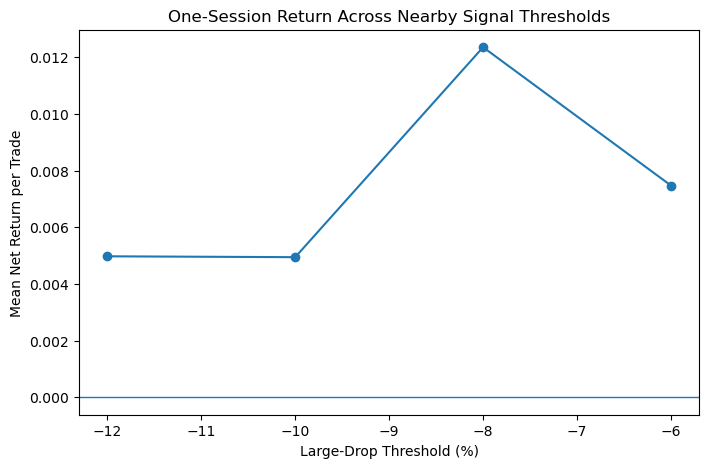

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_summary["Threshold"] * 100,
    threshold_summary["Mean_Net_Return"],
    marker="o"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Large-Drop Threshold (%)")
plt.ylabel("Mean Net Return per Trade")
plt.title("One-Session Return Across Nearby Signal Thresholds")

plt.show()

The objective is **not** to select whichever threshold happens to have the highest historical return.

A healthier result is one where the strategy remains positive across several nearby thresholds. That would suggest a broader effect rather than a single finely tuned cutoff.

## Test 3 — Ticker Concentration

In [11]:
ticker_rows = []

for ticker, ticker_trades in baseline_trades.groupby(
    "Ticker"
):

    summary = summarise_trades(
        ticker_trades,
        ticker
    )

    ticker_rows.append(summary)

ticker_summary = (
    pd.DataFrame(ticker_rows)
    .sort_values(
        "Mean_Net_Return",
        ascending=False
    )
)

ticker_summary[
    [
        "Group",
        "Trades",
        "Mean_Net_Return",
        "Median_Net_Return",
        "Win_Rate",
        "Profit_Factor"
    ]
].style.format({
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Win_Rate": "{:.1%}",
    "Profit_Factor": "{:.2f}"
})

,Group,Trades,Mean_Net_Return,Median_Net_Return,Win_Rate,Profit_Factor
6,MSFT,2,6.09%,6.09%,100.0%,nan
4,JPM,5,3.28%,3.06%,80.0%,18.53
7,NVDA,19,2.15%,1.71%,57.9%,2.85
0,AAPL,5,1.42%,2.06%,80.0%,3.41
1,AMZN,5,0.91%,1.61%,60.0%,2.28
2,GOOGL,4,0.56%,0.76%,50.0%,1.65
3,JNJ,1,0.54%,0.54%,100.0%,nan
5,META,10,0.01%,-0.48%,40.0%,1.01
8,WMT,4,-0.88%,-2.18%,25.0%,0.60
9,XOM,5,-1.28%,-1.91%,40.0%,0.50


### Leave One Ticker Out

In [12]:
leave_one_out_rows = []

for excluded_ticker in tickers:

    reduced_trades = baseline_trades[
        baseline_trades["Ticker"]
        != excluded_ticker
    ]

    summary = summarise_trades(
        reduced_trades,
        f"Without {excluded_ticker}"
    )

    summary["Excluded_Ticker"] = (
        excluded_ticker
    )

    leave_one_out_rows.append(summary)

leave_one_out = pd.DataFrame(
    leave_one_out_rows
)

leave_one_out[
    [
        "Excluded_Ticker",
        "Trades",
        "Mean_Net_Return",
        "Median_Net_Return",
        "Win_Rate",
        "Profit_Factor"
    ]
].style.format({
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Win_Rate": "{:.1%}",
    "Profit_Factor": "{:.2f}"
})

,Excluded_Ticker,Trades,Mean_Net_Return,Median_Net_Return,Win_Rate,Profit_Factor
0,AAPL,55,1.22%,0.66%,54.5%,2.08
1,MSFT,58,1.07%,0.65%,55.2%,1.96
2,AMZN,55,1.26%,0.66%,56.4%,2.14
3,GOOGL,56,1.28%,0.73%,57.1%,2.17
4,META,50,1.48%,1.66%,60.0%,2.35
5,JPM,55,1.05%,0.64%,54.5%,1.90
6,JNJ,59,1.25%,0.80%,55.9%,2.14
7,XOM,55,1.46%,0.80%,58.2%,2.55
8,WMT,56,1.39%,1.21%,58.9%,2.39
9,NVDA,41,0.81%,0.64%,56.1%,1.78


The leave-one-out test is more useful than simply noting that NVDA generated many signals.

If removing any single ticker causes the overall strategy to collapse, the apparent edge may be a stock-specific effect rather than a reusable large-drop signal.

## Test 4 — Performance Through Time

In [13]:
baseline_trades["Signal_Year"] = (
    baseline_trades[
        "Signal_Date"
    ].dt.year
)

year_rows = []

for year, year_trades in baseline_trades.groupby(
    "Signal_Year"
):

    summary = summarise_trades(
        year_trades,
        str(year)
    )

    summary["Year"] = year
    year_rows.append(summary)

year_summary = pd.DataFrame(
    year_rows
)

year_summary[
    [
        "Year",
        "Trades",
        "Mean_Net_Return",
        "Median_Net_Return",
        "Win_Rate"
    ]
].style.format({
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Win_Rate": "{:.1%}"
})

,Year,Trades,Mean_Net_Return,Median_Net_Return,Win_Rate
0,2017,1,4.42%,4.42%,100.0%
1,2018,7,1.53%,0.54%,57.1%
2,2019,2,-0.48%,-0.48%,50.0%
3,2020,24,2.50%,3.15%,75.0%
4,2021,1,-0.38%,-0.38%,0.0%
5,2022,10,-1.27%,-1.18%,20.0%
6,2023,3,-0.74%,-0.83%,0.0%
7,2024,4,1.75%,1.18%,100.0%
8,2025,8,1.04%,0.87%,50.0%


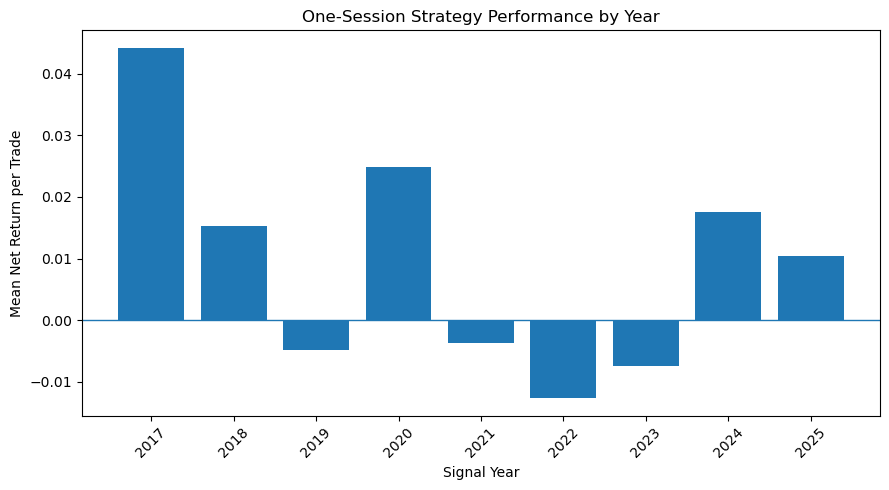

In [14]:
plt.figure(figsize=(9, 5))

plt.bar(
    year_summary["Year"].astype(str),
    year_summary["Mean_Net_Return"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Signal Year")
plt.ylabel("Mean Net Return per Trade")
plt.title("One-Session Strategy Performance by Year")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Remove the 2020 Stress Period

In [15]:
# Simple robustness windows chosen before looking at this output
covid_start = pd.Timestamp("2020-02-20")
covid_end = pd.Timestamp("2020-04-30")

excluding_2020 = baseline_trades[
    baseline_trades["Signal_Year"] != 2020
]

excluding_covid_window = baseline_trades[
    ~baseline_trades["Signal_Date"].between(
        covid_start,
        covid_end
    )
]

period_summary = pd.DataFrame([
    summarise_trades(
        baseline_trades,
        "Full sample"
    ),
    summarise_trades(
        excluding_2020,
        "Excluding 2020"
    ),
    summarise_trades(
        excluding_covid_window,
        "Excluding Feb-Apr 2020"
    )
])

period_summary[
    [
        "Group",
        "Trades",
        "Mean_Net_Return",
        "Median_Net_Return",
        "Win_Rate",
        "Profit_Factor"
    ]
].style.format({
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Win_Rate": "{:.1%}",
    "Profit_Factor": "{:.2f}"
})

,Group,Trades,Mean_Net_Return,Median_Net_Return,Win_Rate,Profit_Factor
0,Full sample,60,1.24%,0.73%,56.7%,2.14
1,Excluding 2020,36,0.40%,-0.48%,44.4%,1.29
2,Excluding Feb-Apr 2020,41,0.38%,-0.48%,43.9%,1.30


## Test 5 — Broad Market Regime

In [16]:
# 200-day moving average of SPY
spy_ma_200 = spy_close.rolling(
    200
).mean()

market_context = pd.DataFrame({
    "SPY_Close": spy_close,
    "SPY_MA_200": spy_ma_200
})

market_context["Market_Regime"] = np.where(
    market_context["SPY_Close"]
    >= market_context["SPY_MA_200"],
    "SPY above 200DMA",
    "SPY below 200DMA"
)

# Join market regime to each large-drop signal date
baseline_with_market = baseline_trades.merge(
    market_context[
        ["Market_Regime"]
    ],
    left_on="Signal_Date",
    right_index=True,
    how="left"
)

regime_rows = []

for regime, regime_trades in baseline_with_market.groupby(
    "Market_Regime"
):

    summary = summarise_trades(
        regime_trades,
        regime
    )

    regime_rows.append(summary)

regime_summary = pd.DataFrame(
    regime_rows
)

regime_summary[
    [
        "Group",
        "Trades",
        "Mean_Net_Return",
        "Median_Net_Return",
        "Win_Rate",
        "Profit_Factor"
    ]
].style.format({
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Win_Rate": "{:.1%}",
    "Profit_Factor": "{:.2f}"
})

,Group,Trades,Mean_Net_Return,Median_Net_Return,Win_Rate,Profit_Factor
0,SPY above 200DMA,22,1.14%,0.48%,54.5%,2.30
1,SPY below 200DMA,38,1.29%,1.80%,57.9%,2.08


The SPY 200-day moving average is used only as a **simple market-regime proxy**.

It is not intended to define a perfect bull or bear market. The purpose is simply to see whether the one-session rebound appears only when the broader market is already in a favourable long-term trend.

## Test 6 — Transaction-Cost Sensitivity

In [17]:
cost_assumptions = [
    0.0000,   # 0.00%
    0.0010,   # 0.10%
    0.0025,   # 0.25%
    0.0050,   # 0.50%
    0.0100    # 1.00%
]

cost_rows = []

for cost in cost_assumptions:

    cost_trades = build_one_session_trades(
        threshold=-0.08,
        transaction_cost=cost
    )

    summary = summarise_trades(
        cost_trades,
        f"{cost:.2%}"
    )

    summary["Round_Trip_Cost"] = cost

    cost_rows.append(summary)

cost_summary = pd.DataFrame(
    cost_rows
)

cost_summary[
    [
        "Round_Trip_Cost",
        "Mean_Net_Return",
        "Median_Net_Return",
        "Win_Rate",
        "Profit_Factor"
    ]
].style.format({
    "Round_Trip_Cost": "{:.2%}",
    "Mean_Net_Return": "{:.2%}",
    "Median_Net_Return": "{:.2%}",
    "Win_Rate": "{:.1%}",
    "Profit_Factor": "{:.2f}"
})

,Round_Trip_Cost,Mean_Net_Return,Median_Net_Return,Win_Rate,Profit_Factor
0,0.00%,1.34%,0.83%,56.7%,2.29
1,0.10%,1.24%,0.73%,56.7%,2.14
2,0.25%,1.09%,0.58%,56.7%,1.95
3,0.50%,0.84%,0.33%,55.0%,1.67
4,1.00%,0.34%,-0.17%,48.3%,1.22


## Results

The robustness tests provide sufficient evidence to progress the one-session strategy to a V1 paper-trading system.

### Matched Baseline

The -8% strategy generated a **1.24% mean net return**, **0.73% median return** and **56.7% win rate**, compared with approximately **-0.05% mean and median returns** and a **48.5% win rate** across matched ordinary trading days.

None of the 1,000 matched control simulations produced a mean return as high as the observed strategy result. The 95% range of control means was **-0.53% to 0.44%**.

A bootstrap analysis of the event trades produced a 95% interval of **0.22% to 2.30%** around the observed 1.24% mean return, indicating uncertainty due to the small sample but retaining a positive average across the interval.

### Robustness Across Thresholds and Stocks

The strategy remained profitable across all nearby drop thresholds tested:

- -6%: **0.75% mean return**
- -8%: **1.24%**
- -10%: **0.49%**
- -12%: **0.50%**

Performance was therefore not dependent on one precise threshold.

NVDA contributed the largest number of signals, but removing it reduced the mean return only to **0.81%**, with a profit factor of **1.78**. Removing any individual ticker left the overall strategy profitable, suggesting that the result is not driven by a single stock.

### Performance Through Time

Performance varied considerably between years. The strategy was particularly strong during **2020**, while 2019, 2021, 2022 and 2023 produced negative average returns.

Excluding 2020 reduced the mean return from **1.24% to 0.40%**, while excluding the February-April 2020 stress period produced a similar **0.38%** mean return. The strategy therefore remains positive without the COVID crash period, but the overall historical result is materially strengthened by extreme market conditions.

### Market Regime and Trading Costs

The strategy remained profitable both when SPY traded above and below its 200-day moving average, producing mean returns of **1.14%** and **1.29%** respectively.

The result was also resilient to higher transaction-cost assumptions. Mean return remained **0.84% at a 0.50% round-trip cost**, although performance weakened substantially at a 1.00% cost.

### Conclusion

The one-session rebound appears sufficiently robust to justify progression to **V1 paper trading**. The effect significantly outperforms matched ordinary trading days, survives nearby signal thresholds and removal of individual stocks, and remains positive outside the 2020 crash period.

However, the limited number of historical events and substantial year-to-year variation mean that the strategy is not yet suitable for live capital. V1 will therefore be used to collect forward paper-trading results while maintaining the simple tested rule: **signal after a daily decline of at least 8%, enter at the following open and exit at the same day's close.**